In [1]:
import numpy as np
from sklearn.datasets import make_regression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler

In [10]:
from qrc_bloqade.encodings import amp_encode, angle_encode, global_encode,position_encode
from qrc_bloqade.hamiltonian import rydberg 
from qrc_bloqade.readouts import ZReadout,EnhancedReadout
from qrc_bloqade.solver import BloqadeSolver 
from qrc_bloqade.utils import(train_split, normalize, get_predictor, print_readout) 
from qrc_bloqade.samples import logistic_map_dataset,lorenz_dataset, analyze_chaos


In [15]:
def test_qrc_angle_encoding():
    n_sites = 4
    V=1.12
    omega=1.12
    time = 1.01

    encoder = angle_encode(n_sites)  # Use AngleEncoding
    readout = ZReadout(n_sites)
    predictor = get_predictor()
    #scaler = MinMaxScaler(feature_range=(-1, 1))
    #splitter = train_split

    # Generate synthetic data
    X, y = lorenz_dataset(n_samples=1000, n_features=n_sites)
    # Normalize data
    X_normalized, y_normalized, scaler_X, scaler_y = normalize(X, y)
   
    # Split data
    X_train, X_val, X_test, y_train, y_val, y_test = train_split(
        X_normalized, y_normalized, test_size=0.4, random_state=402
    )
    print(f"Training set size: {len(X_train)}")
    print(f"Test set size: {len(X_test)}")
    # --- QRC Workflow ---
    # Encode
    encoded_train = encoder.encode(X_train)
    encoded_test = encoder.encode(X_test)
    encoded_train = np.array(encoded_train)
    encoded_test = np.array(encoded_test)

    first_state = encoded_train[0]
    norm = np.sum(np.abs(first_state)**2)
    print(f"First state norm (should be close to 1.0): {norm}")
    print(f"n_sites (qubits): {n_sites}")
    print(f"Expected state size: {2**n_sites}")
    #print(f"Actual train state size: {len(encoded_train)}")
    #print(f"Actual test state size: {len(encoded_test)}")
    print(f"Encoded train shape: {encoded_train.shape}")
    print(f"Encoded test shape: {encoded_test.shape}")
    print(f"First encoded train sample shape: {encoded_train[0].shape}")
    print(f"First encoded test sample shape: {encoded_test[0].shape}")
 
    # Evolve (Dynamics)
    solver = BloqadeSolver()
    evolved_train = []
    evolved_test = []
    ''' best_mse = float('inf')
    best_params = None
    para_count = 0
    for omega in np.arange(1.120, 1.129, 0.001):  # Finer steps
        for V in np.arange(1.120, 1.129, 0.001): 
            para_count += 1
            print(f"Parameter combination {para_count}: omega={round(omega, 2)}, V={round(V, 2)}")
            evolved_train = []
            evolved_test = []'''
    hamiltonian = rydberg(n_sites, omega, V)
    for sample in encoded_train:
            result = solver.simulate_with_history(
                 sample, hamiltonian=hamiltonian.construct_hamiltonian(), 
                 duration=time, steps=100, n_qubits=n_sites)
            evolved_train.append(result)
        
    for sample in encoded_test:
                result = solver.simulate(
            sample, hamiltonian=hamiltonian.construct_hamiltonian(), 
            duration=time, steps=100, n_qubits=n_sites
        )
                evolved_test.append(result)
    
    train_features = readout.measure(evolved_train, n_sites)
    test_features = readout.measure(evolved_test, n_sites)

    print(f"Train features shape: {train_features.shape}")
    print(f"Test features shape: {test_features.shape}")

    # Train
    predictor.fit(train_features, y_train)
    predictions = predictor.predict(test_features)

    # Inverse transform to get original scale
    predictions = scaler_y.inverse_transform(predictions.reshape(-1, 1)).flatten()
    y_test = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()

    mse = mean_squared_error(y_test, predictions)
    print(f"Test MSE (Angle Encoding): {mse}")
    assert mse >= 0  # Just to make sure it runs



In [16]:
# Cell 3: Test function (Amplitude Encoding)
def test_qrc_amplitude_encoding():
    n_sites = 2  # Use only 2 qubits for easier amplitude encoding
    omega = 1.12
    V = 1.12
    time = 1.0

    # QRC components
    hamiltonian = rydberg(n_sites, omega, V)
    encoder = amp_encode(n_sites)  # Use AmplitudeEncoding
    readout = ZReadout(n_sites)
    predictor = get_predictor()
    
    # --- Data Preparation (for amplitude encoding) ---
    # Generate synthetic data with the correct number of features (2^n_sites)
    X, y = make_regression(n_samples=100, n_features=2**n_sites, noise=0.1, random_state=402)
    
    # For amplitude encoding, we need to normalize each sample to have L2 norm = 1
    X_normalized = []
    for sample in X:
        norm = np.linalg.norm(sample)
        X_normalized.append(sample / norm)  # Normalize each sample to unit length
    X_normalized = np.array(X_normalized)
    
    # Normalize y values using scikit-learn scaler
    scaler_y = MinMaxScaler(feature_range=(-1, 1))
    y_normalized = scaler_y.fit_transform(y.reshape(-1, 1)).flatten()
    
    # Split data
    X_train, X_val, X_test, y_train, y_val, y_test= train_split(
        X_normalized, y_normalized, test_size=0.4, random_state=402
    )
    
    # --- QRC Workflow ---
    # Encode
    encoded_train = encoder.encode(X_train)
    encoded_test = encoder.encode(X_test)
    print(f"n_sites (qubits): {n_sites}")
    print(f"Expected state size: {2**n_sites}")
    print(f"Actual train state size: {len(encoded_train)}")
    print(f"Actual test state size: {len(encoded_test)}")
    print(f"Encoded train size: {encoded_train.shape}")
    print(f"Encoded test size: {encoded_test.shape}")

    # Evolve
    solver = BloqadeSolver()
    evolved_train = []
    evolved_test = []
    
    for sample in encoded_train:
        result = solver.simulate(
            sample, hamiltonian=hamiltonian.construct_hamiltonian(), 
            duration=time, steps=100, n_qubits=n_sites
        )
        evolved_train.append(result)
        
    for sample in encoded_test:
        result = solver.simulate(
            sample, hamiltonian=hamiltonian.construct_hamiltonian(), 
            duration=time, steps=100, n_qubits=n_sites
        )
        evolved_test.append(result)

    # Measure
    train_features = readout.measure(evolved_train, n_sites)
    test_features = readout.measure(evolved_test, n_sites)
    
    # Predict
    predictor.fit(train_features, y_train)
    predictions = predictor.predict(test_features)

    # Inverse transform to get original scale
    predictions = scaler_y.inverse_transform(predictions.reshape(-1, 1)).flatten()
    y_test_original = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()

    # Evaluate
    mse = mean_squared_error(y_test_original, predictions)
    print(f"Test MSE (Amplitude Encoding): {mse}")
    assert mse >= 0

In [17]:
def test_qrc_global_encoding():
    n_sites = 4
    time = 1.01
    
    # Use global encoding
    encoder = global_encode(n_sites, encoding_type='hamiltonian')
    readout = ZReadout(n_sites)
    predictor = get_predictor()
    
    # Generate chaotic data (using any of your functions from the chaotic_datasets.py)
    X, y = lorenz_dataset(n_samples=1000, n_features=n_sites)
    
    # Normalize data
    X_normalized, y_normalized, scaler_X, scaler_y = normalize(X, y)
    
    # Split data
    X_train, X_val, X_test, y_train, y_val, y_test = train_split(
        X_normalized, y_normalized, test_size=0.4, random_state=402
    )
    
    # Encode - returns initial states and hamiltonian parameters
    encoded_states_train, hamiltonian_params_train = encoder.encode(X_train)
    encoded_states_test, hamiltonian_params_test = encoder.encode(X_test)
    
    # Evolve with different Hamiltonians for each sample
    solver = BloqadeSolver()
    evolved_train = []
    evolved_test = []
    
    for i, initial_state in enumerate(encoded_states_train):
        params = hamiltonian_params_train[i]
        hamiltonian = rydberg(
            n_sites=n_sites,
            omega=params['omega'],
            V=params['V'],
            detuning_values=params['detuning_values']
        )
        
        result = solver.simulate_with_history(
            initial_state, 
            hamiltonian=hamiltonian.construct_hamiltonian(),
            duration=time, 
            steps=100, 
            n_qubits=n_sites
        )
        evolved_train.append(result)
    
    # Similar process for test data
    for i, initial_state in enumerate(encoded_states_test):
        params = hamiltonian_params_test[i]
        hamiltonian = rydberg(
            n_sites=n_sites,
            omega=params['omega'],
            V=params['V'],
            detuning_values=params['detuning_values']
        )
        
        result = solver.simulate_with_history(
            initial_state, 
            hamiltonian=hamiltonian.construct_hamiltonian(),
            duration=time, 
            steps=100, 
            n_qubits=n_sites
        )
        evolved_test.append(result)
    
    # Continue with readout, training, etc.
    train_features = readout.measure(evolved_train, n_sites)
    test_features = readout.measure(evolved_test, n_sites)
    
    # Train
    predictor.fit(train_features, y_train)
    predictions = predictor.predict(test_features)
    
    # Inverse transform to get original scale
    predictions = scaler_y.inverse_transform(predictions.reshape(-1, 1)).flatten()
    y_test = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()
    
    mse = mean_squared_error(y_test, predictions)
    print(f"Test MSE (Global Encoding): {mse}")

In [18]:
if __name__ == "__main__":
    
    
    print("Running Angle Encoding Test...")
    test_qrc_angle_encoding()
  
    print("\nRunning Amplitude Encoding Test...")
    test_qrc_amplitude_encoding()

Running Angle Encoding Test...
Training set size: 600
Test set size: 200
First state norm (should be close to 1.0): 1.0
n_sites (qubits): 4
Expected state size: 16
Encoded train shape: (600, 16)
Encoded test shape: (200, 16)
First encoded train sample shape: (16,)
First encoded test sample shape: (16,)


AttributeError: 'BloqadeSolver' object has no attribute 'simulate'

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

In [7]:
def test_classical_model():
    n_sites = 4
    
    # Generate the same synthetic data as in your quantum approach
    X, y = lorenz_dataset(n_samples=1000, n_features=n_sites)
    
    # Normalize data
    X_normalized, y_normalized, scaler_X, scaler_y = normalize(X, y)
    
    # Split data using the same method as before
    X_train, X_val, X_test, y_train, y_val, y_test = train_split(
        X_normalized, y_normalized, test_size=0.4, random_state=402
    )
    
    print(f"Training set size: {len(X_train)}")
    print(f"Test set size: {len(X_test)}")
    
    # Try multiple classical methods
    models = {
        "Linear Regression": LinearRegression(),
        "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
        "Gradient Boosting": GradientBoostingRegressor(random_state=42),
        "SVR": SVR(kernel='rbf', C=100, gamma='scale')
    }
    
    results = {}
    
    for name, model in models.items():
        # Train model
        model.fit(X_train, y_train)
        
        # Make predictions
        predictions = model.predict(X_test)
        
        # Inverse transform to get original scale
        predictions = scaler_y.inverse_transform(predictions.reshape(-1, 1)).flatten()
        y_test_original = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()
        
        # Calculate MSE
        mse = mean_squared_error(y_test_original, predictions)
        results[name] = mse
        print(f"{name} MSE: {mse}")
    
    return results

In [8]:
if __name__ == "__main__":
    print("\nRunning Classical Model Test...")
    test_classical_model()


Running Classical Model Test...
Training set size: 600
Test set size: 200


NameError: name 'LinearRegression' is not defined

In [9]:
def test_qrc_global_encoding():
    # Configuration parameters
    n_sites = 4
    time = 1.01
    base_omega = 1.12
    base_V = 1.12
    detuning_scale = 0.5
    
    # Use global encoding with parameters from test function
    encoder = global_encode(
        n_sites=n_sites,
        encoding_type='hamiltonian',
        base_omega=base_omega,
        base_V=base_V,
        detuning_scale=detuning_scale
    )
    readout = ZReadout(n_sites)
    predictor = get_predictor()
    
    # Generate chaotic data
    
    X, y = lorenz_dataset(n_samples=100, n_features=n_sites)
    
    # Normalize data
    X_normalized, y_normalized, scaler_X, scaler_y = normalize(X, y)
    
    # Split data
    X_train, X_val, X_test, y_train, y_val, y_test = train_split(
        X_normalized, y_normalized, test_size=0.4, random_state=402
    )
    
    # Encode
    encoded_states_train, hamiltonian_params_train = encoder.encode(X_train)
    encoded_states_test, hamiltonian_params_test = encoder.encode(X_test)
    
    # Evolve with different Hamiltonians for each sample
    solver = BloqadeSolver()
    evolved_train = []
    evolved_test = []
    
    for i, initial_state in enumerate(encoded_states_train):
        params = hamiltonian_params_train[i]
        hamiltonian = rydberg(
            n_sites=n_sites,
            omega=params['omega'],
            V=params['V'],
            detuning_values=params['detuning_values']
        )
        
        result = solver.simulate(
            initial_state, 
            hamiltonian=hamiltonian.construct_hamiltonian(),
            duration=time, 
            steps=100, 
            n_qubits=n_sites
        )
        evolved_train.append(result)
    
    # Similar process for test data
    for i, initial_state in enumerate(encoded_states_test):
        params = hamiltonian_params_test[i]
        hamiltonian = rydberg(
            n_sites=n_sites,
            omega=params['omega'],
            V=params['V'],
            detuning_values=params['detuning_values']
        )
        
        result = solver.simulate(
            initial_state, 
            hamiltonian=hamiltonian.construct_hamiltonian(),
            duration=time, 
            steps=100, 
            n_qubits=n_sites
        )
        evolved_test.append(result)
    
    # Continue with readout, training, etc.
    train_features = readout.measure(evolved_train, n_sites)
    test_features = readout.measure(evolved_test, n_sites)
    
    # Train
    predictor.fit(train_features, y_train)
    predictions = predictor.predict(test_features)
    
    # Inverse transform to get original scale
    predictions = scaler_y.inverse_transform(predictions.reshape(-1, 1)).flatten()
    y_test = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()
    
    mse = mean_squared_error(y_test, predictions)
    print(f"Test MSE (Global Encoding): {mse}")

In [10]:
if __name__ == "__main__":
 print("\nRunning Amplitude Encoding Test...")
test_qrc_global_encoding()


Running Amplitude Encoding Test...


AttributeError: 'BloqadeSolver' object has no attribute 'simulate'

In [3]:
from sklearn.ensemble import RandomForestRegressor

In [15]:
def test_qrc_vs_classical():
    print("DEBUG: Starting test_qrc_vs_classical function")
    
    # Configuration parameters
    n_sites = 4
    time = 1.01
    base_omega = 1.12
    base_V = 1.12
    detuning_scale = 0.5
    
    print(f"DEBUG: Configuration - n_sites={n_sites}, time={time}, omega={base_omega}, V={base_V}")
    
    # Use global encoding with parameters from test function
    print("DEBUG: Creating encoder")
    encoder = global_encode(
        n_sites=n_sites,
        encoding_type='hamiltonian',
        base_omega=base_omega,
        base_V=base_V,
        detuning_scale=detuning_scale
    )
    
    print("DEBUG: Creating readout")
    readout = EnhancedReadout(n_sites, include_zz=True, include_multi_time=True, time_points=[50, 100, 150])
    print(f"DEBUG: Readout created with time_points={readout.time_points}, include_multi_time={readout.include_multi_time}")
    
    print("DEBUG: Creating predictors")
    predictor_qrc = get_predictor()
    predictor_rf = RandomForestRegressor(n_estimators=100, random_state=402)
    
    # Generate chaotic data
    print("DEBUG: Generating Lorenz dataset")
    X, y = lorenz_dataset(n_samples=500, n_features=n_sites)
    print(f"DEBUG: Dataset created with shape X:{X.shape}, y:{y.shape}")
    
    # Visualize dataset
    print("DEBUG: Analyzing chaos")
    analyze_chaos("Lorenz Attractor", lorenz_dataset, n_samples=500, n_features=n_sites)
    
    # Normalize data
    print("DEBUG: Normalizing data")
    X_normalized, y_normalized, scaler_X, scaler_y = normalize(X, y)
    
    # Split data
    print("DEBUG: Splitting data")
    X_train, X_val, X_test, y_train, y_val, y_test = train_split(
        X_normalized, y_normalized, test_size=0.4, random_state=402
    )
    print(f"DEBUG: Split sizes - Train:{X_train.shape}, Val+Test:{X_test.shape}")
    
    # Encode for QRC
    print("DEBUG: Encoding for QRC")
    encoded_states_train, hamiltonian_params_train = encoder.encode(X_train)
    encoded_states_test, hamiltonian_params_test = encoder.encode(X_test)
    print(f"DEBUG: Encoded states sizes - Train:{len(encoded_states_train)}, Test:{len(encoded_states_test)}")
    
    # Evolve with different Hamiltonians for each sample
    print("DEBUG: Creating solver")
    solver = BloqadeSolver()
    evolved_train = []
    evolved_test = []
    
    print("DEBUG: Evolving training states")
    for i, initial_state in enumerate(encoded_states_train):
        print(f"DEBUG: Evolving training sample {i+1}/{len(encoded_states_train)}")
        params = hamiltonian_params_train[i]
        hamiltonian = rydberg(
            n_sites=n_sites,
            omega=params['omega'],
            V=params['V'],
            detuning_values=params['detuning_values']
        )
        
        # Use return_all_steps=True to get states at all time steps
        result = solver.simulate_with_history(
            initial_state,
            hamiltonian=hamiltonian.construct_hamiltonian(),
            duration=time,
            steps=200,
            n_qubits=n_sites,
          
        )
        evolved_train.append(result)
    
    print("DEBUG: Evolving test states")
    for i, initial_state in enumerate(encoded_states_test):
        print(f"DEBUG: Evolving test sample {i+1}/{len(encoded_states_test)}")
        params = hamiltonian_params_test[i]
        hamiltonian = rydberg(
            n_sites=n_sites,
            omega=params['omega'],
            V=params['V'],
            detuning_values=params['detuning_values']
        )
        
        # Use return_all_steps=True to get states at all time steps
        result = solver.simulate_with_history(
            initial_state,
            hamiltonian=hamiltonian.construct_hamiltonian(),
            duration=time,
            steps=200,
            n_qubits=n_sites,
         
        )
        evolved_test.append(result)
    
    # Readout for QRC
    print("DEBUG: Measuring QRC features")
    print(f"DEBUG: Type of first evolved_train element: {type(evolved_train[0])}")
    print(f"DEBUG: Length of first evolved_train element: {len(evolved_train[0])}")
    train_features_qrc = readout.measure(evolved_train, n_sites)
    test_features_qrc = readout.measure(evolved_test, n_sites)
    print(f"DEBUG: Feature shapes - Train:{train_features_qrc.shape}, Test:{test_features_qrc.shape}")
    
    # Train QRC predictor
    print("DEBUG: Training QRC predictor")
    predictor_qrc.fit(train_features_qrc, y_train)
    predictions_qrc = predictor_qrc.predict(test_features_qrc)
    
    # Train Classical RandomForest
    print("DEBUG: Training Random Forest predictor")
    predictor_rf.fit(X_train, y_train)
    predictions_rf = predictor_rf.predict(X_test)
    
    # Inverse transform to get original scale
    print("DEBUG: Inverse transforming predictions")
    predictions_qrc = scaler_y.inverse_transform(predictions_qrc.reshape(-1, 1)).flatten()
    predictions_rf = scaler_y.inverse_transform(predictions_rf.reshape(-1, 1)).flatten()
    y_test = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()
    
    # Compute MSE
    print("DEBUG: Computing MSE")
    mse_qrc = mean_squared_error(y_test, predictions_qrc)
    mse_rf = mean_squared_error(y_test, predictions_rf)
    
    print(f"Test MSE (Quantum Reservoir Computing): {mse_qrc}")
    print(f"Test MSE (Random Forest): {mse_rf}")


Running test Encoding Test...
DEBUG: Starting test_qrc_vs_classical function
DEBUG: Configuration - n_sites=4, time=1.01, omega=1.12, V=1.12
DEBUG: Creating encoder
DEBUG: Creating readout
DEBUG: Readout created with time_points=[50, 100, 150], include_multi_time=True
DEBUG: Creating predictors
DEBUG: Generating Lorenz dataset
DEBUG: Dataset created with shape X:(500, 4), y:(500,)
DEBUG: Analyzing chaos


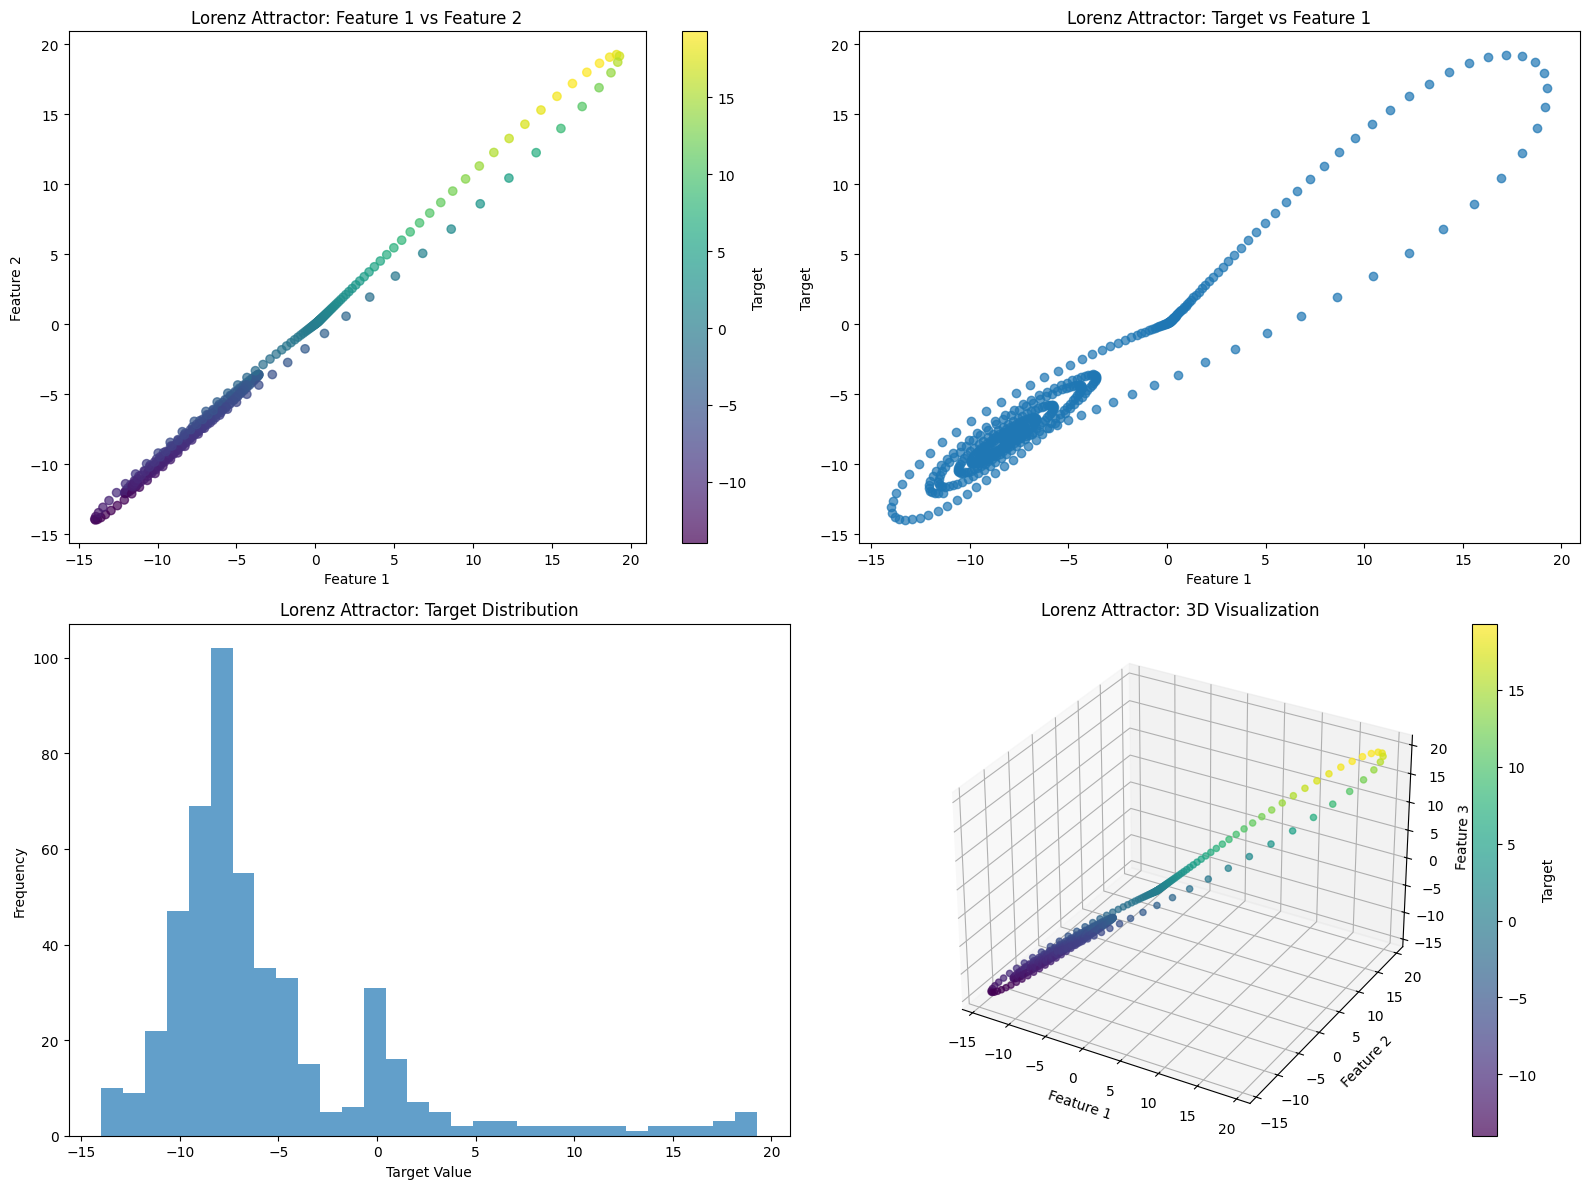


=== Lorenz Attractor Dataset Analysis ===
Shape: (500, 4), (500,)
Feature range: [-13.9832, 19.2761]
Target range: [-13.9832, 19.2761]

Feature Correlation Matrix:
[[1.         0.99807728 0.99233253 0.98284514]
 [0.99807728 1.         0.9980729  0.99231307]
 [0.99233253 0.9980729  1.         0.9980675 ]
 [0.98284514 0.99231307 0.9980675  1.        ]]

Feature-Target Correlations:
[0.96975111 0.98279735 0.99228967 0.99806115]


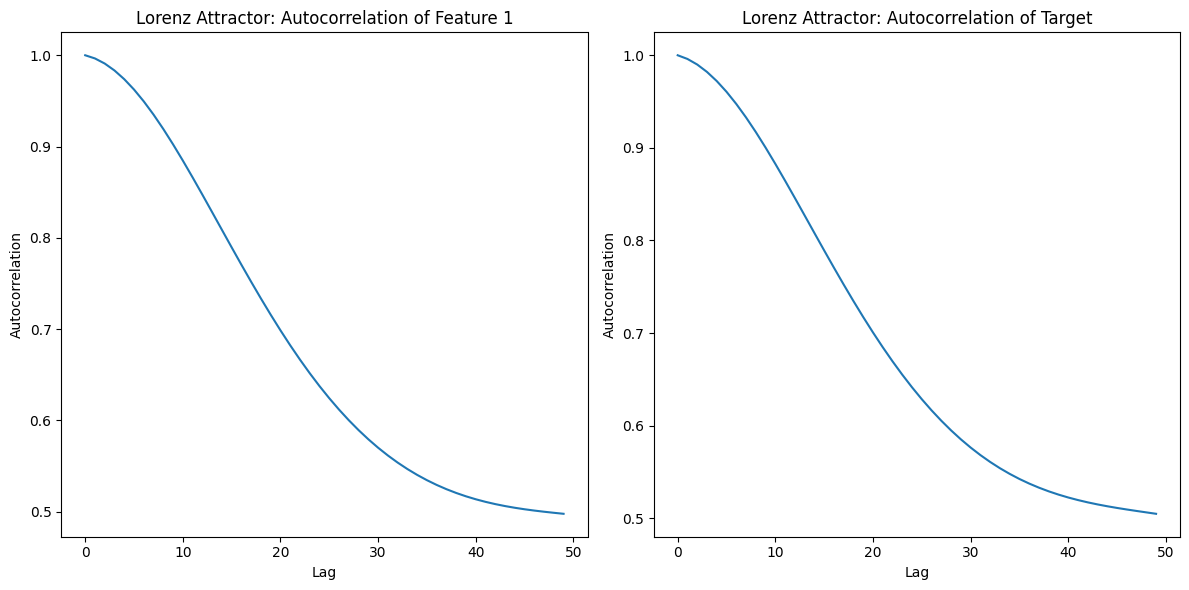

DEBUG: Normalizing data
DEBUG: Splitting data
DEBUG: Split sizes - Train:(300, 4), Val+Test:(100, 4)
DEBUG: Encoding for QRC
DEBUG: Encoded states sizes - Train:300, Test:100
DEBUG: Creating solver
DEBUG: Evolving training states
DEBUG: Evolving training sample 1/300


AttributeError: 'BloqadeSolver' object has no attribute 'simulate'

In [16]:
if __name__ == "__main__":
 print("\nRunning test Encoding Test...")
test_qrc_vs_classical()